Task was destroyed but it is pending!
task: <Task pending name='Task-69' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\ProgramData\anaconda3\envs\personality_llm\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-70' coro=<_async_in_context.<locals>.preserve_context() running at C:\ProgramData\anaconda3\envs\personality_llm\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\ProgramData\anaconda3\envs\personality_llm\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\ProgramData\anaconda3\envs\personality_llm\lib\tokenize.py:527: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  pseudomatch = _compile(PseudoToken).match(line, pos)
Task was destroyed but it is pending!
task: <Task pending name='Task-70' coro=<_async_in_context.<locals>.preserve_context() running at C:\ProgramData\anaconda3\envs\personality_llm\lib\site-

Paths ready
Train dataframe: (800, 28)
Style features: (800, 24)
Number of labels: 6
BERT embeddings: (800, 768)
LLM feature file exists, but it is not aligned with train data.
Expected rows: 800 Actual rows: 300
Available LLM columns: ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism', 'llm_confidence']
Using Style + BERT only.
Final X shape: (800, 792)
Style dim: 24
BERT dim: 768
LLM dim: 0
Classes: [1 2 3 4 5 6]
Feature schema saved: C:\Users\Neda\Desktop\personality_llm\models\hybrid_feature_schema.json
Train: (640, 792)
Validation: (160, 792)
Hybrid stacking model is ready.
Running 5-fold CV. This may take some time...
5-Fold Macro F1: [0.80620408 0.83840439 0.7781363  0.82466392 0.78069222]
Mean Macro F1: 0.8056201836719097
Std Macro F1: 0.02372583445590754
Training final hybrid model...
Training completed.

HYBRID STACKING RESULTS
Accuracy: 0.75625
Macro F1: 0.7544643568299482

Classification Report:
              precision    recall  f1-score   sup

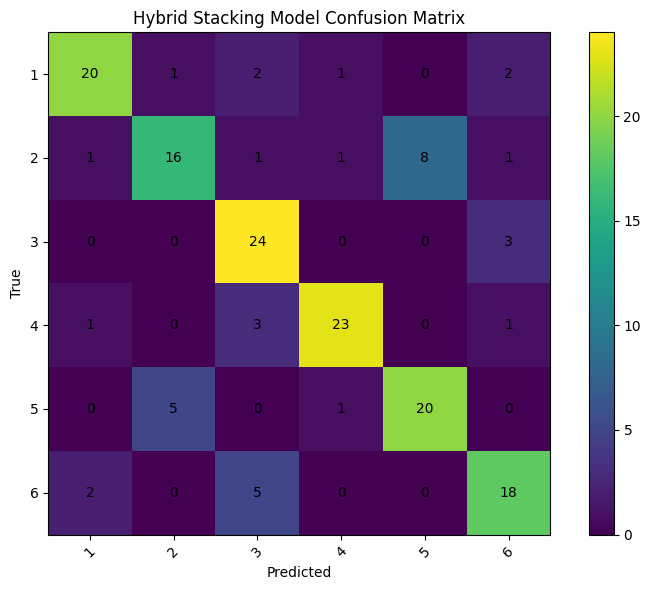

Calculating permutation importance...
Saved model: C:\Users\Neda\Desktop\personality_llm\models\hybrid_stacking_model.pkl
Saved schema: C:\Users\Neda\Desktop\personality_llm\models\hybrid_feature_schema.json
Saved results.

FINAL SUMMARY
Architecture: Style RF + ParsBERT LR + XGBoost Fusion → Logistic Meta Classifier
Use LLM Features: False
Validation Accuracy: 0.75625
Validation Macro F1: 0.7544643568299482
CV Macro F1 Mean: 0.8056201836719097
CV Macro F1 Std: 0.02372583445590754
✔ DONE


In [2]:

import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

# =========================================
# 1. PATHS
# =========================================

BASE_PATH = r"C:\Users\Neda\Desktop\personality_llm"

FEATURES_PATH = os.path.join(BASE_PATH, "data", "features")
EMBEDDINGS_PATH = os.path.join(BASE_PATH, "data", "embeddings")
MODELS_PATH = os.path.join(BASE_PATH, "models")
RESULTS_PATH = os.path.join(BASE_PATH, "results")

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

TRAIN_FEATURES_PATH = os.path.join(FEATURES_PATH, "train_features.csv")
TRAIN_BERT_PATH = os.path.join(EMBEDDINGS_PATH, "train_bert.npy")
LLM_FEATURES_PATH = os.path.join(FEATURES_PATH, "llm_personality_features.csv")

print("Paths ready")



# =========================================
# 2. LOAD STYLE FEATURES AND LABELS
# =========================================

train_df = pd.read_csv(TRAIN_FEATURES_PATH)

ID_COLUMNS = ["text", "label", "clean_text", "tokens"]
STYLE_COLUMNS = train_df.drop(columns=ID_COLUMNS, errors="ignore").columns.tolist()

X_style_df = train_df[STYLE_COLUMNS].copy().fillna(0)
y_raw = train_df["label"].values

print("Train dataframe:", train_df.shape)
print("Style features:", X_style_df.shape)
print("Number of labels:", len(np.unique(y_raw)))



# =========================================
# 3. LOAD PARSBERT EMBEDDINGS
# =========================================

X_bert = np.load(TRAIN_BERT_PATH)

print("BERT embeddings:", X_bert.shape)
assert len(X_style_df) == len(X_bert), "Mismatch between train_features.csv and train_bert.npy"

BERT_DIM = X_bert.shape[1]



# =========================================
# 4. OPTIONAL: LOAD LLM PERSONALITY FEATURES
# =========================================
# اگر فایل llm_personality_features.csv وجود داشته باشد و تعداد ردیف‌هایش با train برابر باشد، وارد مدل می‌شود.
# اگر وجود نداشته باشد، مدل فقط با Style + BERT اجرا می‌شود.

LLM_FEATURE_COLUMNS = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
    "llm_confidence",
]

use_llm_features = False
X_llm = None

if os.path.exists(LLM_FEATURES_PATH):
    llm_df = pd.read_csv(LLM_FEATURES_PATH)
    available_cols = [c for c in LLM_FEATURE_COLUMNS if c in llm_df.columns]

    if len(available_cols) == len(LLM_FEATURE_COLUMNS) and len(llm_df) == len(train_df):
        X_llm = llm_df[LLM_FEATURE_COLUMNS].fillna(0).values
        use_llm_features = True
        print("LLM features loaded:", X_llm.shape)
    else:
        print("LLM feature file exists, but it is not aligned with train data.")
        print("Expected rows:", len(train_df), "Actual rows:", len(llm_df))
        print("Available LLM columns:", available_cols)
        print("Using Style + BERT only.")
else:
    print("No LLM feature file found. Using Style + BERT only.")



# =========================================
# 5. FEATURE FUSION
# =========================================

X_style = X_style_df.values

if use_llm_features:
    X = np.hstack([X_style, X_bert, X_llm])
else:
    X = np.hstack([X_style, X_bert])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

style_dim = X_style.shape[1]
bert_dim = X_bert.shape[1]
llm_dim = X_llm.shape[1] if use_llm_features else 0

total_dim = X.shape[1]

style_indices = list(range(0, style_dim))
bert_indices = list(range(style_dim, style_dim + bert_dim))
llm_indices = list(range(style_dim + bert_dim, total_dim)) if use_llm_features else []
all_indices = list(range(total_dim))

print("Final X shape:", X.shape)
print("Style dim:", style_dim)
print("BERT dim:", bert_dim)
print("LLM dim:", llm_dim)
print("Classes:", label_encoder.classes_)

joblib.dump(label_encoder, os.path.join(MODELS_PATH, "label_encoder.pkl"))



# =========================================
# 6. SAVE FEATURE SCHEMA FOR INFERENCE
# =========================================

feature_schema = {
    "style_columns": STYLE_COLUMNS,
    "style_dim": style_dim,
    "bert_dim": bert_dim,
    "llm_feature_columns": LLM_FEATURE_COLUMNS if use_llm_features else [],
    "llm_dim": llm_dim,
    "use_llm_features": use_llm_features,
    "total_dim": total_dim,
}

SCHEMA_PATH = os.path.join(MODELS_PATH, "hybrid_feature_schema.json")
with open(SCHEMA_PATH, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

print("Feature schema saved:", SCHEMA_PATH)



# =========================================
# 7. TRAIN / VALIDATION SPLIT
# =========================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)



# =========================================
# 8. HYBRID STACKING MODEL
# =========================================
# این معماری از سه مسیر استفاده می‌کند:
# 1) مدل مخصوص ویژگی‌های سبک نوشتاری
# 2) مدل مخصوص embeddingهای ParsBERT
# 3) مدل fusion روی همه ویژگی‌ها
# سپس Logistic Regression به عنوان meta-classifier تصمیم نهایی را می‌گیرد.

style_preprocessor = ColumnTransformer(
    transformers=[("style", "passthrough", style_indices)],
    remainder="drop"
)

bert_preprocessor = ColumnTransformer(
    transformers=[("bert", "passthrough", bert_indices)],
    remainder="drop"
)

all_preprocessor = ColumnTransformer(
    transformers=[("all", "passthrough", all_indices)],
    remainder="drop"
)

style_model = Pipeline(steps=[
    ("select_style", style_preprocessor),
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

bert_model = Pipeline(steps=[
    ("select_bert", bert_preprocessor),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_fusion_model = Pipeline(steps=[
    ("select_all", all_preprocessor),
    ("xgb", XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

hybrid_model = StackingClassifier(
    estimators=[
        ("style_rf", style_model),
        ("bert_lr", bert_model),
        ("xgb_fusion", xgb_fusion_model),
    ],
    final_estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

print("Hybrid stacking model is ready.")



# =========================================
# 9. CROSS VALIDATION
# =========================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold CV. This may take some time...")
cv_f1 = cross_val_score(
    hybrid_model,
    X,
    y,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

cv_results = {
    "cv_macro_f1_mean": float(cv_f1.mean()),
    "cv_macro_f1_std": float(cv_f1.std()),
    "cv_scores": cv_f1.tolist(),
}

print("5-Fold Macro F1:", cv_f1)
print("Mean Macro F1:", cv_f1.mean())
print("Std Macro F1:", cv_f1.std())

pd.DataFrame([cv_results]).to_csv(
    os.path.join(RESULTS_PATH, "hybrid_cv_results.csv"),
    index=False,
    encoding="utf-8-sig"
)



# =========================================
# 10. TRAIN FINAL MODEL ON TRAIN SPLIT
# =========================================

print("Training final hybrid model...")
hybrid_model.fit(X_train, y_train)
print("Training completed.")



# =========================================
# 11. EVALUATION ON VALIDATION SET
# =========================================

y_pred = hybrid_model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average="macro")

print("\n====================")
print("HYBRID STACKING RESULTS")
print("====================")
print("Accuracy:", acc)
print("Macro F1:", f1)

report = classification_report(
    y_val,
    y_pred,
    target_names=[str(c) for c in label_encoder.classes_],
    output_dict=True
)

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_pred,
    target_names=[str(c) for c in label_encoder.classes_]
))



# =========================================
# 12. CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Hybrid Stacking Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "hybrid_stacking_confusion_matrix.png"), dpi=300)
plt.show()



# =========================================
# 13. PERMUTATION IMPORTANCE FOR THESIS EXPLAINABILITY
# =========================================
# برای سریع‌تر شدن، فقط روی validation محاسبه می‌کنیم.

print("Calculating permutation importance...")

perm = permutation_importance(
    hybrid_model,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

feature_names = (
    [f"style::{c}" for c in STYLE_COLUMNS]
    + [f"bert::{i}" for i in range(bert_dim)]
    + ([f"llm::{c}" for c in LLM_FEATURE_COLUMNS] if use_llm_features else [])
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.to_csv(
    os.path.join(RESULTS_PATH, "hybrid_permutation_importance.csv"),
    index=False,
    encoding="utf-8-sig"
)

importance_df.head(20)



# =========================================
# 14. SAVE MODEL AND RESULTS
# =========================================

MODEL_PATH = os.path.join(MODELS_PATH, "hybrid_stacking_model.pkl")
LEGACY_MODEL_PATH = os.path.join(MODELS_PATH, "hybrid_model.pkl")

joblib.dump(hybrid_model, MODEL_PATH)
joblib.dump(hybrid_model, LEGACY_MODEL_PATH)  # برای سازگاری با demo قبلی

results = {
    "model": "Hybrid Stacking: Style + ParsBERT" + (" + LLM" if use_llm_features else ""),
    "accuracy": acc,
    "macro_f1": f1,
    "cv_macro_f1_mean": float(cv_f1.mean()),
    "cv_macro_f1_std": float(cv_f1.std()),
    "use_llm_features": use_llm_features,
    "style_dim": style_dim,
    "bert_dim": bert_dim,
    "llm_dim": llm_dim,
    "total_dim": total_dim,
}

pd.DataFrame([results]).to_csv(
    os.path.join(RESULTS_PATH, "hybrid_stacking_results.csv"),
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame(report).T.to_csv(
    os.path.join(RESULTS_PATH, "hybrid_stacking_classification_report.csv"),
    encoding="utf-8-sig"
)

print("Saved model:", MODEL_PATH)
print("Saved schema:", SCHEMA_PATH)
print("Saved results.")



# =========================================
# 15. FINAL SUMMARY
# =========================================

print("\n====================")
print("FINAL SUMMARY")
print("====================")
print("Architecture: Style RF + ParsBERT LR + XGBoost Fusion → Logistic Meta Classifier")
print("Use LLM Features:", use_llm_features)
print("Validation Accuracy:", acc)
print("Validation Macro F1:", f1)
print("CV Macro F1 Mean:", cv_f1.mean())
print("CV Macro F1 Std:", cv_f1.std())
print("✔ DONE")


